# 03 — Raster Preprocessing
**Step 3 of Urban Expansion vs Economic Activity pipeline**

Takes GeoTIFFs from `01_gibs_tile_fetcher` and prepares them for CNN input.

| Step | Operation |
|------|-----------|
| 1 | Inventory — verify all expected files exist |
| 2 | Reproject VIIRS to match MODIS grid (resample zoom-5 → zoom-6) |
| 3 | Normalize bands consistently across years and cities |
| 4 | Simple cloud/bright-pixel mask on MODIS RGB |
| 5 | Stack into `(years, H, W, C)` tensors per metro |
| 6 | Time-aware split by year (train 2014–2018 / val 2019 / test 2021–2023; 2020 excluded from evaluation) |
| 7 | Save tensors + metadata to `data/tensors/` |

**Input:**  `data/imagery/{metro}/{layer}/{year}.tif`
**Output:** `data/tensors/{metro}_stack.npz` + `data/tensors/metadata.json`

In [1]:
!pip install rasterio numpy scipy matplotlib tqdm --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 1. Imports & Configuration

In [2]:
import os
import json
import glob
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── Directory paths ──────────────────────────────────────────────────────────
IMAGERY_DIR = "data/imagery"
TENSOR_DIR  = "data/tensors"
os.makedirs(TENSOR_DIR, exist_ok=True)

# ── Metros and year ranges (must match notebook 01) ──────────────────────────
METROS = [
    "atlanta", "austin", "charlotte", "dallas", "denver", "houston",
    "jacksonville", "las_vegas", "nashville", "orlando", "phoenix",
    "raleigh", "san_antonio", "tampa",
]

MODIS_YEARS = list(range(2013, 2024))   # 2013–2023, 11 years
VIIRS_YEARS = list(range(2017, 2024))   # 2017–2023,  7 years
ALL_YEARS   = MODIS_YEARS               # full tensor years
EXCLUDE_YEAR = 2020

# ── Train / val / test split by year (no temporal leakage) ───────────────────
TRAIN_YEARS = list(range(2014, 2019))   # 2014–2018
VAL_YEARS   = [2019]                    # 2019 only
TEST_YEARS  = list(range(2021, 2024))   # 2021–2023

# ── Band layout in final tensor ───────────────────────────────────────────────
# Ch 0,1,2 = MODIS RGB    (always present 2013–2023)
# Ch 3     = VIIRS night  (present 2017–2023, zero-filled for 2013–2016)
N_CHANNELS = 4

print(f"Metros      : {METROS}")
print(f"MODIS years : {MODIS_YEARS[0]}–{MODIS_YEARS[-1]}  ({len(MODIS_YEARS)} years)")
print(f"VIIRS years : {VIIRS_YEARS[0]}–{VIIRS_YEARS[-1]}  ({len(VIIRS_YEARS)} years)")
print(f"Train/val/test: {TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]} / {VAL_YEARS[0]} / {TEST_YEARS[0]}–{TEST_YEARS[-1]} (2020 excluded)")


Metros      : ['atlanta', 'austin', 'charlotte', 'dallas', 'denver', 'houston', 'jacksonville', 'las_vegas', 'nashville', 'orlando', 'phoenix', 'raleigh', 'san_antonio', 'tampa']
MODIS years : 2013–2023  (11 years)
VIIRS years : 2017–2023  (7 years)
Train/val/test: 2014–2018 / 2019 / 2021–2023 (2020 excluded)


## 2. Inventory — Verify Expected Files

In [3]:
def inventory(metros, modis_years, viirs_years, imagery_dir):
    """Check all expected GeoTIFFs exist. Print missing files."""
    missing = []
    present = []
    for metro in metros:
        for year in modis_years:
            p = os.path.join(imagery_dir, metro, "modis_rgb", f"{year}.tif")
            (present if os.path.exists(p) else missing).append(p)
        for year in viirs_years:
            p = os.path.join(imagery_dir, metro, "viirs_night", f"{year}.tif")
            (present if os.path.exists(p) else missing).append(p)

    total = len(present) + len(missing)
    print(f"Files present : {len(present)} / {total}")
    if missing:
        print(f"Files MISSING : {len(missing)}")
        for f in missing:
            print(f"  ✗ {f}")
    else:
        print("✓ All files present")
    return missing

missing = inventory(METROS, MODIS_YEARS, VIIRS_YEARS, IMAGERY_DIR)


Files present : 252 / 252
✓ All files present


## 3. Helper — Read GeoTIFF as float32 Array

In [4]:
def read_tif(path, n_bands=None):
    """
    Read a GeoTIFF and return:
      arr      : float32 ndarray (H, W, bands), values in [0, 1]
      profile  : rasterio profile dict (CRS, transform, shape)
    Returns None, None if file missing.
    """
    if not os.path.exists(path):
        return None, None
    with rasterio.open(path) as src:
        data    = src.read()          # (bands, H, W) uint8
        profile = src.profile.copy()
    arr = data.astype(np.float32) / 255.0   # normalise to [0,1]
    arr = np.transpose(arr, (1, 2, 0))      # → (H, W, bands)
    return arr, profile


## 4. Cloud / Bright-Pixel Mask on MODIS RGB

In [5]:
def cloud_mask(rgb_arr, threshold=0.95):
    """
    Simple cloud mask: pixels where ALL three channels > threshold
    are likely cloud/snow. Set them to 0.
    Returns masked array (in-place copy).
    """
    arr = rgb_arr.copy()
    cloud = np.all(arr > threshold, axis=-1)   # (H, W) bool
    arr[cloud] = 0.0
    pct = cloud.mean() * 100
    return arr, pct

# Quick test on one file
test_path = os.path.join(IMAGERY_DIR, METROS[0], "modis_rgb", "2020.tif")
if os.path.exists(test_path):
    rgb, _ = read_tif(test_path)
    masked, pct = cloud_mask(rgb)
    print(f"Cloud pixels masked: {pct:.1f}% of {METROS[0]} 2020")
else:
    print(f"[SKIP] test file not found: {test_path}")


Cloud pixels masked: 0.1% of atlanta 2020


## 5. Reproject VIIRS to Match MODIS Grid

In [6]:
def resample_viirs_to_modis(viirs_arr, viirs_profile, modis_profile):
    """
    Reproject/resample VIIRS (zoom-5, ~500m) onto the MODIS grid (zoom-6, ~250m).
    Uses bilinear resampling.

    viirs_arr     : (H_v, W_v, 1) float32
    viirs_profile : rasterio profile for VIIRS
    modis_profile : rasterio profile for MODIS (target grid)

    Returns (H_m, W_m, 1) float32 resampled array.
    """
    dst_h = modis_profile["height"]
    dst_w = modis_profile["width"]
    dst   = np.zeros((dst_h, dst_w), dtype=np.float32)

    src_arr = np.transpose(viirs_arr, (2, 0, 1))[0]   # (H_v, W_v)

    reproject(
        source      = src_arr,
        destination = dst,
        src_transform  = viirs_profile["transform"],
        src_crs        = viirs_profile["crs"],
        dst_transform  = modis_profile["transform"],
        dst_crs        = modis_profile["crs"],
        resampling     = Resampling.bilinear,
    )
    return dst[:, :, np.newaxis]   # → (H_m, W_m, 1)


## 6. Per-Metro Min-Max Normalisation for VIIRS

In [7]:
def compute_viirs_stats(metros, viirs_years, imagery_dir):
    """
    Compute global min/max of VIIRS night-lights across all metros and years.
    Used to normalise VIIRS to [0,1] consistently.
    """
    all_vals = []
    for metro in metros:
        for year in viirs_years:
            p = os.path.join(imagery_dir, metro, "viirs_night", f"{year}.tif")
            if not os.path.exists(p):
                continue
            with rasterio.open(p) as src:
                data = src.read(1).astype(np.float32)
            # Ignore zero-fill (nodata) pixels
            all_vals.append(data[data > 0])

    if not all_vals:
        print("[WARN] No VIIRS files found — using default range [0, 255]")
        return 0.0, 255.0

    flat  = np.concatenate(all_vals)
    vmin  = float(np.percentile(flat, 1))    # 1st percentile — ignore outliers
    vmax  = float(np.percentile(flat, 99))   # 99th percentile
    print(f"VIIRS global stats — p1: {vmin:.2f}  p99: {vmax:.2f}")
    return vmin, vmax

viirs_min, viirs_max = compute_viirs_stats(METROS, VIIRS_YEARS, IMAGERY_DIR)


VIIRS global stats — p1: 11.00  p99: 218.00


## 7. Build Per-Metro Tensor Stack

In [8]:
def build_metro_tensor(metro, all_years, viirs_years, imagery_dir,
                       viirs_min, viirs_max, n_channels=4):
    """
    Build a (T, H, W, C) tensor for one metro:
      T = len(all_years)
      H, W = MODIS spatial dims for this metro
      C = 4  (RGB + night-lights)

    VIIRS is resampled to MODIS grid.
    Years before VIIRS availability (pre-2017) get channel 3 = 0.
    Returns tensor (float32) and reference MODIS profile.
    """
    # Get spatial dims from first available MODIS file
    ref_profile = None
    ref_h, ref_w = None, None
    for year in all_years:
        p = os.path.join(imagery_dir, metro, "modis_rgb", f"{year}.tif")
        if os.path.exists(p):
            with rasterio.open(p) as src:
                ref_profile = src.profile.copy()
                ref_h, ref_w = src.height, src.width
            break

    if ref_profile is None:
        print(f"  [WARN] {metro}: no MODIS files found — skipping")
        return None, None

    T = len(all_years)
    tensor = np.zeros((T, ref_h, ref_w, n_channels), dtype=np.float32)

    for t, year in enumerate(tqdm(all_years, desc=metro, ncols=80)):

        # ── MODIS RGB (channels 0-2) ─────────────────────────────────────
        modis_path = os.path.join(imagery_dir, metro, "modis_rgb", f"{year}.tif")
        rgb, _ = read_tif(modis_path, n_bands=3)
        if rgb is not None:
            rgb, cloud_pct = cloud_mask(rgb)
            # Resize if shape mismatch (should not happen but defensive)
            if rgb.shape[:2] != (ref_h, ref_w):
                from PIL import Image as PILImage
                rgb_img = PILImage.fromarray((rgb * 255).astype(np.uint8).reshape(ref_h, ref_w, 3)
                                              if rgb.shape[:2] == (ref_h, ref_w)
                                              else (rgb * 255).astype(np.uint8))
                rgb = np.array(rgb_img.resize((ref_w, ref_h))) / 255.0
            tensor[t, :, :, :3] = rgb
        else:
            print(f"  [WARN] {metro} {year}: MODIS missing")

        # ── VIIRS night-lights (channel 3) ───────────────────────────────
        if year in viirs_years:
            viirs_path = os.path.join(imagery_dir, metro, "viirs_night", f"{year}.tif")
            viirs_raw, viirs_profile = read_tif(viirs_path, n_bands=1)
            if viirs_raw is not None:
                # Normalise VIIRS using global p1/p99 stats
                viirs_norm = (viirs_raw * 255.0 - viirs_min) / max(viirs_max - viirs_min, 1e-6)
                viirs_norm = np.clip(viirs_norm, 0.0, 1.0)
                # Resample to MODIS grid
                viirs_resampled = resample_viirs_to_modis(
                    viirs_norm, viirs_profile, ref_profile
                )
                tensor[t, :, :, 3:4] = viirs_resampled
            else:
                print(f"  [WARN] {metro} {year}: VIIRS missing")
        # else: channel 3 stays 0 (pre-2017)

    return tensor, ref_profile


# ── Build tensors for all metros ─────────────────────────────────────────────
tensors   = {}
profiles  = {}

for metro in METROS:
    print(f"\n── {metro.upper()} ──")
    t, p = build_metro_tensor(
        metro, ALL_YEARS, VIIRS_YEARS, IMAGERY_DIR,
        viirs_min, viirs_max, N_CHANNELS
    )
    if t is not None:
        tensors[metro]  = t
        profiles[metro] = p
        print(f"  Tensor shape: {t.shape}  dtype: {t.dtype}  "
              f"min={t.min():.3f}  max={t.max():.3f}")



── ATLANTA ──


atlanta:   0%|                                           | 0/11 [00:00<?, ?it/s]

atlanta:  45%|███████████████▉                   | 5/11 [00:00<00:00, 33.83it/s]

atlanta:  82%|████████████████████████████▋      | 9/11 [00:00<00:00, 28.07it/s]

atlanta: 100%|██████████████████████████████████| 11/11 [00:00<00:00, 28.37it/s]

...

san_antonio: 100%|██████████████████████████████| 11/11 [00:00<00:00, 62.49it/s]

  Tensor shape: (11, 512, 1024, 4)  dtype: float32  min=0.000  max=1.000

── TAMPA ──


tampa:   0%|                                             | 0/11 [00:00<?, ?it/s]

tampa: 100%|███████████████████████████████████| 11/11 [00:00<00:00, 121.46it/s]

  Tensor shape: (11, 512, 512, 4)  dtype: float32  min=0.000  max=1.000


## 8. Train / Val / Test Split

In [9]:
def year_split(all_years, train_years, val_years, test_years):
    """Return index arrays for train/val/test splits by year."""
    idx = {y: i for i, y in enumerate(all_years)}
    return (
        np.array([idx[y] for y in train_years if y in idx]),
        np.array([idx[y] for y in val_years   if y in idx]),
        np.array([idx[y] for y in test_years  if y in idx]),
    )

train_idx, val_idx, test_idx = year_split(ALL_YEARS, TRAIN_YEARS, VAL_YEARS, TEST_YEARS)

print(f"Train indices : {train_idx}  → years {[ALL_YEARS[i] for i in train_idx]}")
print(f"Val   indices : {val_idx}    → years {[ALL_YEARS[i] for i in val_idx]}")
print(f"Test  indices : {test_idx}  → years {[ALL_YEARS[i] for i in test_idx]}")

print(f"Excluded year : {EXCLUDE_YEAR} (kept in tensors but omitted from split indices)")


Train indices : [1 2 3 4 5]  → years [2014, 2015, 2016, 2017, 2018]
Val   indices : [6]    → years [2019]
Test  indices : [ 8  9 10]  → years [2021, 2022, 2023]
Excluded year : 2020 (kept in tensors but omitted from split indices)


## 9. Save Tensors to Disk

In [10]:
for metro, tensor in tensors.items():
    out_path = os.path.join(TENSOR_DIR, f"{metro}_stack.npz")
    np.savez_compressed(
        out_path,
        tensor     = tensor,           # (T, H, W, C)
        years      = np.array(ALL_YEARS),
        train_idx  = train_idx,
        val_idx    = val_idx,
        test_idx   = test_idx,
    )
    size_mb = os.path.getsize(out_path) / 1e6
    print(f"Saved {out_path}  ({size_mb:.1f} MB)")

# Save metadata JSON
meta = {
    "metros":       METROS,
    "all_years":    ALL_YEARS,
    "train_years":  TRAIN_YEARS,
    "val_years":    VAL_YEARS,
    "exclude_year": EXCLUDE_YEAR,
    "test_years":   TEST_YEARS,
    "n_channels":   N_CHANNELS,
    "channels":     ["modis_R", "modis_G", "modis_B", "viirs_night"],
    "viirs_min":    viirs_min,
    "viirs_max":    viirs_max,
    "viirs_years":  VIIRS_YEARS,
    "note_viirs":   "channel 3 = 0 for years before 2017 (VIIRS not available)",
}
meta_path = os.path.join(TENSOR_DIR, "metadata.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print(f"Saved {meta_path}")


Saved data/tensors/atlanta_stack.npz  (47.0 MB)


Saved data/tensors/austin_stack.npz  (13.9 MB)


Saved data/tensors/charlotte_stack.npz  (11.5 MB)


Saved data/tensors/dallas_stack.npz  (14.8 MB)


Saved data/tensors/denver_stack.npz  (12.4 MB)


...

Saved data/tensors/orlando_stack.npz  (11.4 MB)


Saved data/tensors/phoenix_stack.npz  (27.6 MB)


Saved data/tensors/raleigh_stack.npz  (25.1 MB)


Saved data/tensors/san_antonio_stack.npz  (27.3 MB)


Saved data/tensors/tampa_stack.npz  (11.9 MB)
Saved data/tensors/metadata.json


## 10. Visual Check — One Metro, Two Years

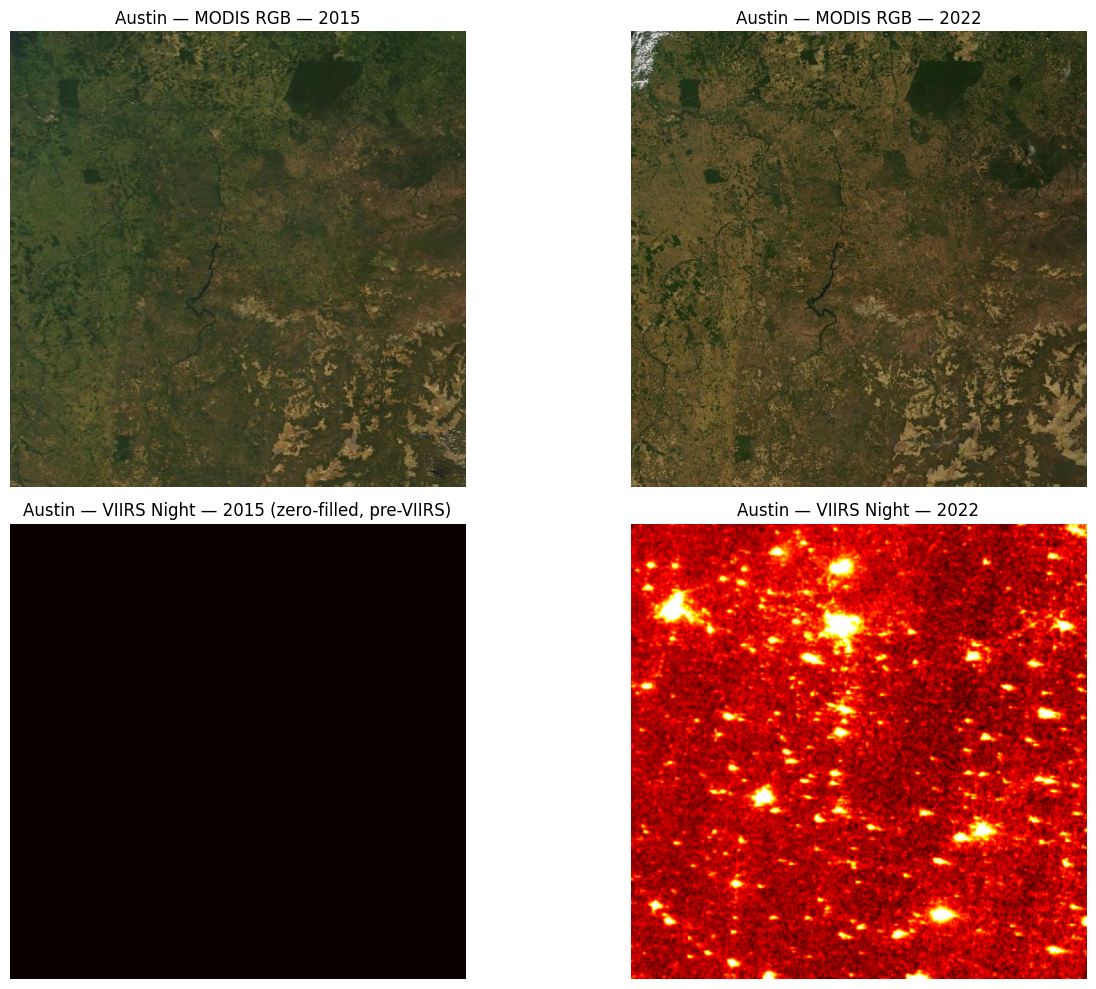

In [11]:
PREVIEW_METRO = "austin"
PREVIEW_YEARS = [2015, 2022]   # pre-VIIRS vs recent

if PREVIEW_METRO in tensors:
    tensor = tensors[PREVIEW_METRO]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col, year in enumerate(PREVIEW_YEARS):
        if year not in ALL_YEARS:
            continue
        t = ALL_YEARS.index(year)
        rgb   = tensor[t, :, :, :3]
        night = tensor[t, :, :,  3]

        axes[0, col].imshow(rgb)
        axes[0, col].set_title(f"{PREVIEW_METRO.title()} — MODIS RGB — {year}")
        axes[0, col].axis("off")

        axes[1, col].imshow(night, cmap="hot", vmin=0, vmax=1)
        axes[1, col].set_title(f"{PREVIEW_METRO.title()} — VIIRS Night — {year}"
                               + (" (zero-filled, pre-VIIRS)" if year < 2017 else ""))
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"[SKIP] {PREVIEW_METRO} tensor not built")


In [12]:
import rasterio, numpy as np
with rasterio.open("data/imagery/austin/viirs_night/2022.tif") as src:
    arr = src.read(1)
print(f"shape: {arr.shape}")
print(f"min: {arr.min()}, max: {arr.max()}, mean: {arr.mean():.2f}")
print(f"non-zero pixels: {(arr > 0).sum()}")

shape: (512, 512)
min: 7, max: 255, mean: 76.90
non-zero pixels: 262144


In [13]:
import rasterio, numpy as np, os

for year in range(2017, 2024):
    p = f"data/imagery/austin/viirs_night/{year}.tif"
    if not os.path.exists(p):
        print(f"{year}: FILE MISSING")
        continue
    with rasterio.open(p) as src:
        arr = src.read(1)
    print(f"{year}: shape={arr.shape}  max={arr.max()}  non-zero={( arr > 0).sum()}")

2017: shape=(512, 512)  max=255  non-zero=262144
2018: shape=(512, 512)  max=255  non-zero=262144
2019: shape=(512, 512)  max=255  non-zero=262144
2020: shape=(512, 512)  max=255  non-zero=262144
2021: shape=(512, 512)  max=255  non-zero=262144
2022: shape=(512, 512)  max=255  non-zero=262144
2023: shape=(512, 512)  max=255  non-zero=262144


## Output Structure
```
data/tensors/
├── {metro}_stack.npz      # one file per metro; keys: tensor(T,H,W,4), years, train_idx, val_idx, test_idx
└── metadata.json          # channel names, year ranges, VIIRS normalisation stats
```

**Channel layout per pixel:**
| Ch | Source | Years available | Range |
|----|--------|-----------------|-------|
| 0  | MODIS R | 2013–2023 | [0,1] |
| 1  | MODIS G | 2013–2023 | [0,1] |
| 2  | MODIS B | 2013–2023 | [0,1] |
| 3  | VIIRS night | 2017–2023 (0 before) | [0,1] |

**Next step → refreshed EDA / modeling notebooks that consume these tensors**